В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

# Download the module from GitHub into the working directory
module_url = 'https://raw.githubusercontent.com/Margo2368/ML_homework/main/process_bank_churn.py'
!wget -q -O process_bank_churn.py {module_url}

from process_bank_churn import preprocess_data, preprocess_new_data

print([f for f in os.listdir('.') if f.endswith('.py')])
print()
print(open('process_bank_churn.py').readline())

['process_bank_churn.py']

import pandas as pd



**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [3]:
raw_df = pd.read_csv('train.csv')
data = preprocess_data(raw_df, scaler_numeric=False)

X_train = data['X_train']
train_targets = data['train_targets']
X_val = data['X_val']
val_targets = data['val_targets']

print('X_train:', X_train.shape, '| X_val:', X_val.shape)
print()
print('Колонки X_train:', list(X_train.columns))
print()
print('Баланс класів (train):')
print(train_targets.value_counts(normalize=True).round(3))
X_train.head()

X_train: (12000, 13) | X_val: (3000, 13)

Колонки X_train: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']

Баланс класів (train):
Exited
0.0    0.796
1.0    0.204
Name: proportion, dtype: float64


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,682.0,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,1.0,0.0,0.0,0.0,1.0
10393,684.0,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,1.0,0.0,0.0,1.0,0.0
80,705.0,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0,1.0,0.0,0.0,1.0
3365,669.0,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0,0.0,1.0,0.0,1.0
12236,707.0,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,1.0,0.0,0.0,0.0,1.0


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, train_targets)

train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

print('AUROC Training: {:.4f}'.format(roc_auc_score(train_targets, train_probs)))
print('AUROC Validation: {:.4f}'.format(roc_auc_score(val_targets, val_probs)))
print()
print('Глибина дерева:', model.tree_.max_depth)
print('Кількість листків:', model.tree_.n_leaves)

AUROC Training: 1.0000
AUROC Validation: 0.7700

Глибина дерева: 26
Кількість листків: 1332


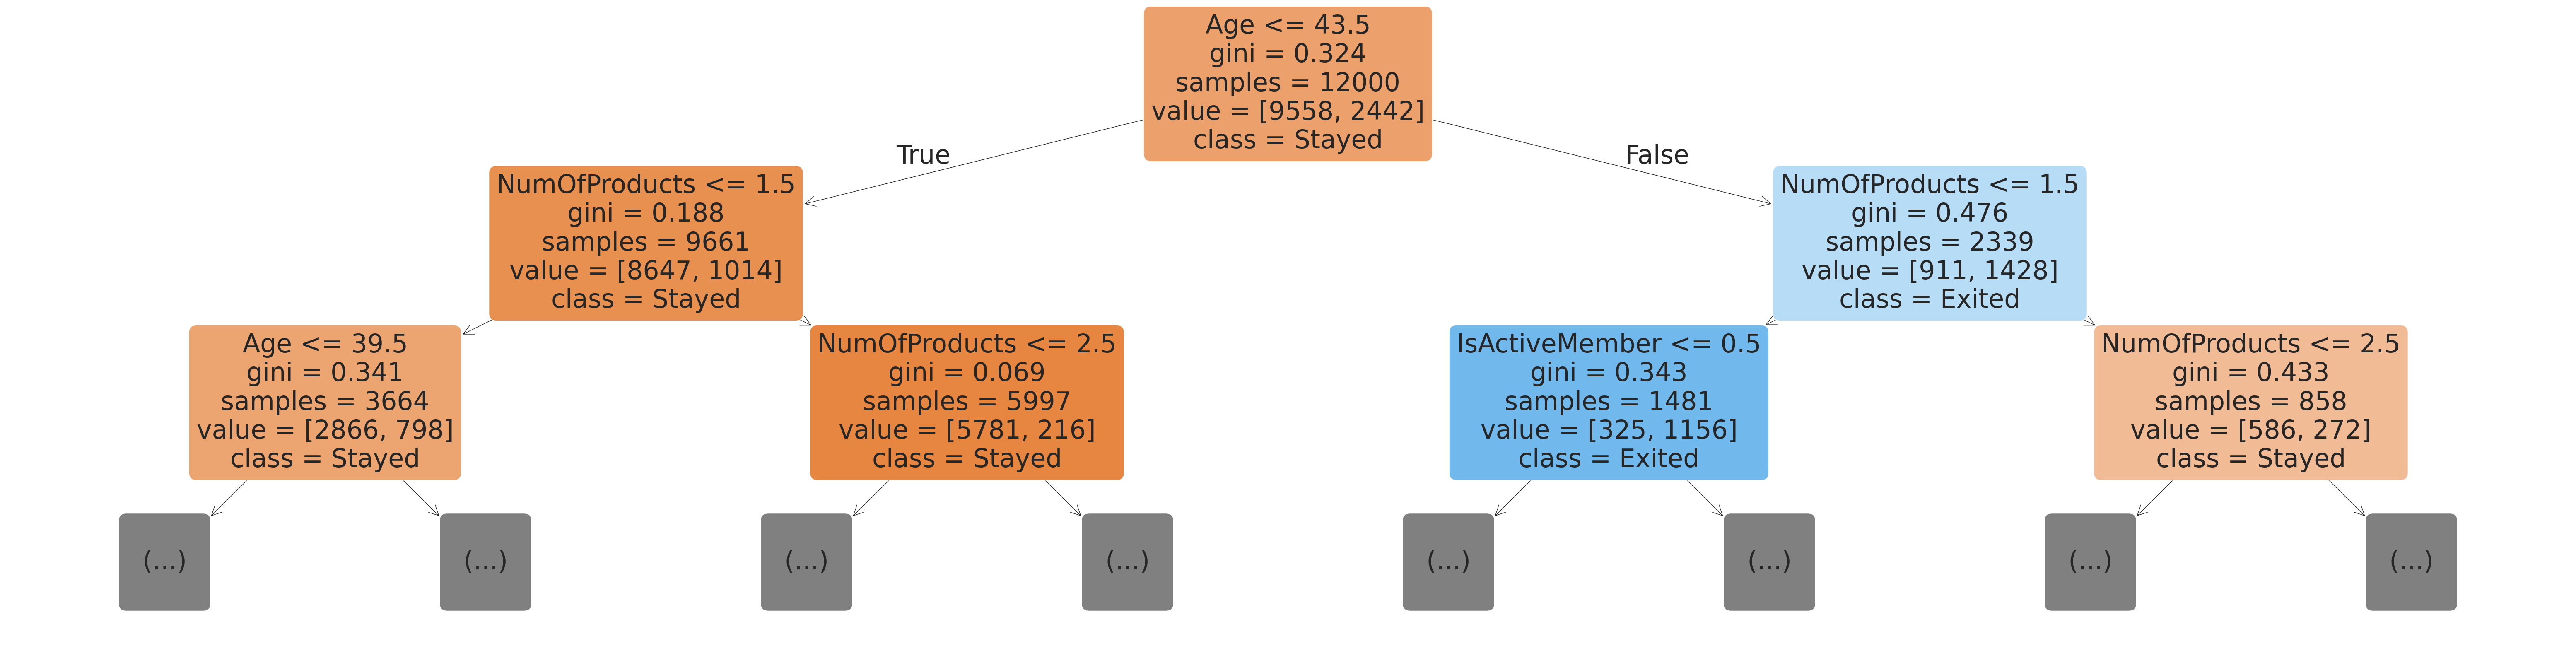

In [5]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(80, 20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True,
          rounded=True, class_names=['Stayed', 'Exited']);

,feature,importance
1,Age,0.356789
4,NumOfProducts,0.168379
7,EstimatedSalary,0.123635
0,CreditScore,0.123283
3,Balance,0.079192
2,Tenure,0.052899
6,IsActiveMember,0.032688
11,Gender_Female,0.014908
9,Geography_Germany,0.014725
5,HasCrCard,0.012957


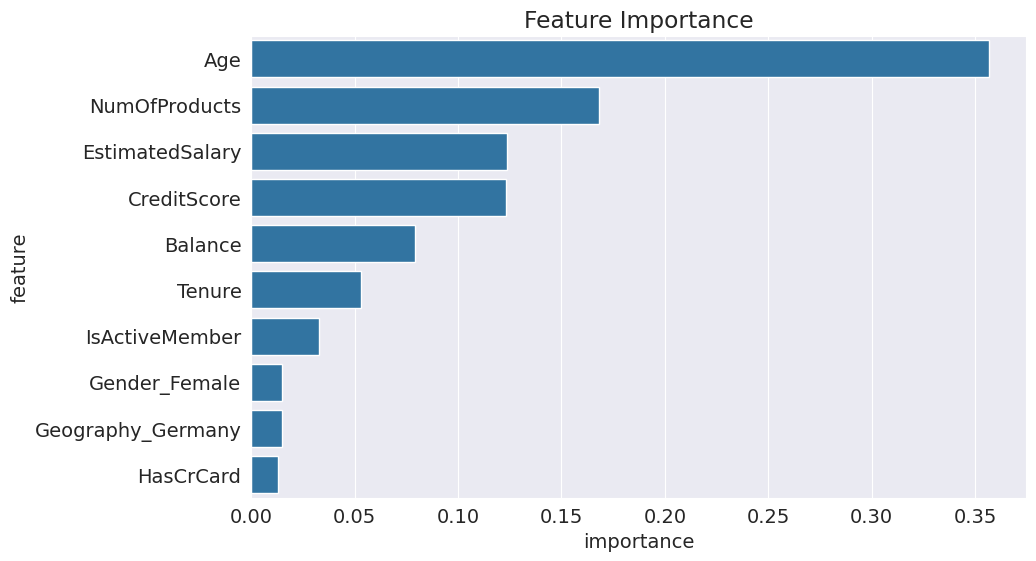

In [6]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(10))

plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

### Висновки до завдання 2

**Модель сильно перенавчена.** Дерево з параметрами за замовчуванням досягає AUROC = 1.0000 на тренувальних даних і лише 0.7700 на валідаційних. Розрив у 0.23 означає, що модель запам'ятала тренувальну вибірку, а не вловила загальні закономірності.

Для порівняння: логістична регресія з ДЗ 2.2 давала AUROC ≈ 0.88 на валідації. Тобто нерегуляризоване дерево наразі **гірше** за простішу модель, і його потрібно обмежувати гіперпараметрами.

**Найвпливовіші ознаки за структурою дерева** (перші два рівні):

- `Age` — кореневий вузол з порогом 43.5. Серед клієнтів до 43.5 років пішли лише 10.5%, серед старших - 61%.
- `NumOfProducts` — поріг 1.5 в обох гілках другого рівня. Найчистіший вузол дерева (gini = 0.069) - молоді клієнти з двома і більше продуктами: відтік лише 3.6%.
- `IsActiveMember` - третій рівень у найризикованішій групі: серед старших клієнтів з одним продуктом неактивні йдуть найчастіше.

**Feature importances частково розходяться з цією картиною.** `Age` (0.357) і `NumOfProducts` (0.168) очікувано лідирують, але на 3–4 місцях опинилися `EstimatedSalary` (0.124) та `CreditScore` (0.123), яким логістична регресія давала майже нульові ваги. Навпаки, бінарна `IsActiveMember` (0.033) виглядає недооціненою, бо може бути використана лише один раз на кожному шляху.

Висновок: інтерпретувати feature importances у перенавченому дереві слід обережно - надійнішими є верхні рівні структури дерева.

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [7]:
def try_params(max_depth=None, max_leaf_nodes=None):
    model = DecisionTreeClassifier(max_depth=max_depth,
                                   max_leaf_nodes=max_leaf_nodes,
                                   random_state=42)
    model.fit(X_train, train_targets)
    train_auroc = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
    val_auroc = roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])
    return {'Max Depth': max_depth, 'Max Leaf Nodes': max_leaf_nodes,
            'Train AUROC': train_auroc, 'Validation AUROC': val_auroc}

params_list = [
    {'max_depth': None, 'max_leaf_nodes': None},
    {'max_depth': 3, 'max_leaf_nodes': None},
    {'max_depth': 5, 'max_leaf_nodes': None},
    {'max_depth': 7, 'max_leaf_nodes': None},
    {'max_depth': 10, 'max_leaf_nodes': None},
    {'max_depth': None, 'max_leaf_nodes': 16},
    {'max_depth': None, 'max_leaf_nodes': 32},
    {'max_depth': None, 'max_leaf_nodes': 64},
    {'max_depth': 5, 'max_leaf_nodes': 16},
    {'max_depth': 7, 'max_leaf_nodes': 32},
    {'max_depth': 10, 'max_leaf_nodes': 64},
]

results_df = pd.DataFrame([try_params(**p) for p in params_list])
results_df.style.background_gradient(subset='Validation AUROC', cmap='Blues')

,Max Depth,Max Leaf Nodes,Train AUROC,Validation AUROC
0,nan,nan,1.000000,0.769953
1,3.000000,nan,0.897184,0.891146
2,5.000000,nan,0.925694,0.921927
3,7.000000,nan,0.941535,0.914449
4,10.000000,nan,0.969765,0.848436
5,nan,16.000000,0.914511,0.913572
6,nan,32.000000,0.922074,0.918667
7,nan,64.000000,0.933060,0.919112
8,5.000000,16.000000,0.913863,0.913946
9,7.000000,32.000000,0.922037,0.918765


In [8]:
fine_params_list = [
    {'max_depth': 4, 'max_leaf_nodes': None},
    {'max_depth': 5, 'max_leaf_nodes': None},
    {'max_depth': 6, 'max_leaf_nodes': None},
    {'max_depth': 5, 'max_leaf_nodes': 24},
    {'max_depth': 5, 'max_leaf_nodes': 48},
    {'max_depth': 6, 'max_leaf_nodes': 48},
    {'max_depth': 6, 'max_leaf_nodes': 96},
]

fine_results_df = pd.DataFrame([try_params(**p) for p in fine_params_list])
fine_results_df.style.background_gradient(subset='Validation AUROC', cmap='Blues')

,Max Depth,Max Leaf Nodes,Train AUROC,Validation AUROC
0,4,nan,0.911281,0.911264
1,5,nan,0.925694,0.921927
2,6,nan,0.933778,0.921111
3,5,24.000000,0.922288,0.920007
4,5,48.000000,0.925694,0.921927
5,6,48.000000,0.932176,0.922378
6,6,96.000000,0.933778,0.921424


In [9]:
model = DecisionTreeClassifier(max_depth=6, max_leaf_nodes=48, random_state=42)
model.fit(X_train, train_targets)

print('Найкращі параметри: max_depth=6, max_leaf_nodes=48')
print()
print('AUROC Training: {:.4f}'.format(roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])))
print('AUROC Validation: {:.4f}'.format(roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])))
print()
print('Глибина дерева:', model.tree_.max_depth)
print('Кількість листків:', model.tree_.n_leaves)

Найкращі параметри: max_depth=6, max_leaf_nodes=48

AUROC Training: 0.9322
AUROC Validation: 0.9224

Глибина дерева: 6
Кількість листків: 48


### Висновки до завдання 3

Методом «тика» перевірено 18 комбінацій `max_depth` та `max_leaf_nodes` - спочатку грубою сіткою, потім дрібнішим кроком навколо лідера.

**Найкращий результат: `max_depth=6, max_leaf_nodes=48`**




**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [10]:
def max_depth_auroc(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_auroc = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
    val_auroc = roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])
    return {'Max Depth': md, 'Train AUROC': train_auroc, 'Validation AUROC': val_auroc}

auroc_df = pd.DataFrame([max_depth_auroc(md) for md in range(1, 21)])
auroc_df.style.background_gradient(subset='Validation AUROC', cmap='Blues')

,Max Depth,Train AUROC,Validation AUROC
0,1,0.744727,0.734865
1,2,0.842908,0.846496
2,3,0.897184,0.891146
3,4,0.911281,0.911264
4,5,0.925694,0.921927
5,6,0.933778,0.921111
6,7,0.941535,0.914449
7,8,0.949541,0.902790
8,9,0.959079,0.884709
9,10,0.969765,0.848436


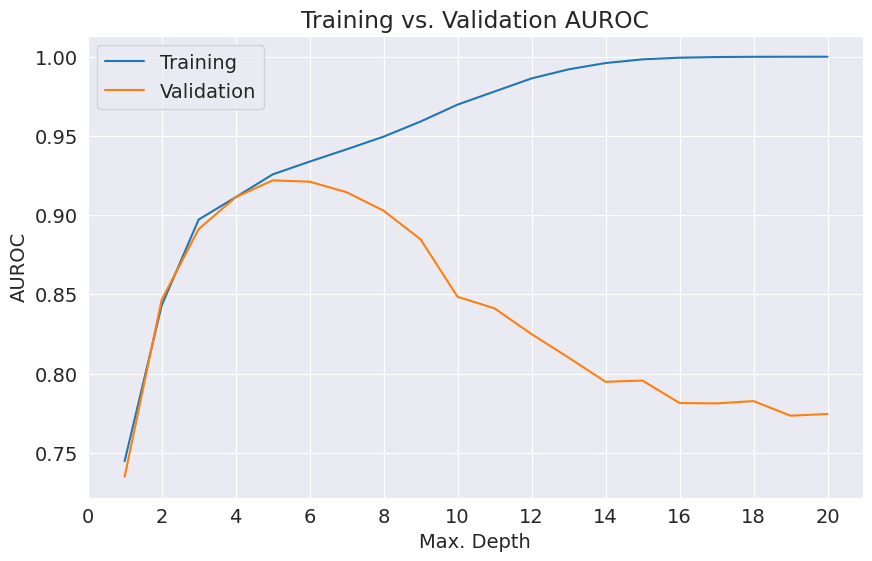

In [11]:
plt.figure()
plt.plot(auroc_df['Max Depth'], auroc_df['Train AUROC'])
plt.plot(auroc_df['Max Depth'], auroc_df['Validation AUROC'])
plt.title('Training vs. Validation AUROC')
plt.xticks(range(0, 21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('AUROC')
plt.legend(['Training', 'Validation']);

### Висновки до завдання 4

Побудовано залежність AUROC від `max_depth` у діапазоні від 1 до 20 на тренувальних і валідаційних даних.

**Оптимальна глибина - 5**, з валідаційним AUROC = 0.9219.

Графік демонструє класичний патерн і чітко ділиться на три фази:

1. **Недонавчання (глибина 1–4).** Обидві криві зростають майже злито: від 0.745/0.735 до 0.911/0.911. Модель занадто проста і не встигає вловити закономірності в даних - вона однаково погано працює і на тренувальних, і на валідаційних даних.

2. **Оптимум (глибина 5).** Валідаційний AUROC досягає максимуму 0.9219 при тренувальному 0.9257. Це найкращий баланс між складністю моделі та здатністю узагальнювати.

3. **Перенавчання (глибина 6–20).** Криві розходяться «ножицями». Тренувальний AUROC зростає до 0.99999 і виходить на плато після глибини 15 - дерево запам'ятало всі приклади. Валідаційний AUROC при цьому падає до 0.774, втративши 0.15 від пікового значення.


**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [12]:
final_model = DecisionTreeClassifier(max_depth=5, random_state=42)
final_model.fit(X_train, train_targets)

print('Фінальна модель: max_depth=5')
print()
print('AUROC Training: {:.4f}'.format(roc_auc_score(train_targets, final_model.predict_proba(X_train)[:, 1])))
print('AUROC Validation: {:.4f}'.format(roc_auc_score(val_targets, final_model.predict_proba(X_val)[:, 1])))
print()
print('Глибина дерева:', final_model.tree_.max_depth)
print('Кількість листків:', final_model.tree_.n_leaves)

Фінальна модель: max_depth=5

AUROC Training: 0.9257
AUROC Validation: 0.9219

Глибина дерева: 5
Кількість листків: 29


In [13]:
test_raw_df = pd.read_csv('test.csv')

X_test = preprocess_new_data(test_raw_df,
                             numeric_cols=data['numeric_cols'],
                             categorical_cols=data['categorical_cols'],
                             encoder=data['encoder'],
                             imputer=data['imputer'],
                             scaler=None)

print('test_raw_df.shape :', test_raw_df.shape)
print('X_test.shape :', X_test.shape)
print()
print('Колонки збігаються з X_train:', list(X_test.columns) == list(X_train.columns))
print('Пропуски в X_test:', X_test.isna().sum().sum())
X_test.head()

test_raw_df.shape : (10000, 13)
X_test.shape : (10000, 13)

Колонки збігаються з X_train: True
Пропуски в X_test: 0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,584.0,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.0,1.0,0.0,0.0,1.0
1,551.0,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,1.0,0.0,0.0,0.0,1.0
2,706.0,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,1.0,0.0,0.0,0.0,1.0
3,717.0,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.0,0.0,1.0,0.0,1.0
4,592.0,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.0,0.0,1.0,0.0,1.0


In [14]:
test_probs = final_model.predict_proba(X_test)[:, 1]

test_raw_df['Exited'] = test_probs

print('Розподіл прогнозованих ймовірностей:')
print(test_raw_df.Exited.describe().round(4))
print()
print('Унікальних значень ймовірності:', test_raw_df.Exited.nunique())
print('Середня прогнозована ймовірність: {:.4f}'.format(test_probs.mean()))
print('Частка класу 1 у тренувальних даних: {:.4f}'.format(train_targets.mean()))
test_raw_df[['id', 'Geography', 'Gender', 'Age', 'Exited']].head()

Розподіл прогнозованих ймовірностей:
count    10000.0000
mean         0.2079
std          0.2946
min          0.0000
25%          0.0089
50%          0.0417
75%          0.2379
max          1.0000
Name: Exited, dtype: float64

Унікальних значень ймовірності: 28
Середня прогнозована ймовірність: 0.2079
Частка класу 1 у тренувальних даних: 0.2035


,id,Geography,Gender,Age,Exited
0,15000,Germany,Male,30.0,0.237911
1,15001,France,Male,39.0,0.027613
2,15002,France,Male,43.0,0.027613
3,15003,Spain,Male,45.0,0.770925
4,15004,Spain,Male,43.0,0.027613


In [15]:
sample_submission_df = pd.read_csv('sample_submission.csv')

submission_df = sample_submission_df[['id']].merge(test_raw_df[['id', 'Exited']], on='id', how='left')

print('submission_df.shape :', submission_df.shape)
print('Пропуски після merge:', submission_df.Exited.isna().sum())
display(submission_df.head())

# Save without row indices
submission_df.to_csv('submission_decision_tree.csv', index=False)

print()
print('Перевірка збереженого файлу:')
print(pd.read_csv('submission_decision_tree.csv').head())

submission_df.shape : (10000, 2)
Пропуски після merge: 0


,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.770925
4,15004,0.027613



Перевірка збереженого файлу:
      id    Exited
0  15000  0.237911
1  15001  0.027613
2  15002  0.027613
3  15003  0.770925
4  15004  0.027613


In [16]:
from google.colab import files

files.download('submission_decision_tree.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>